In [1]:
import os
import h5py
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_curve, log_loss, brier_score_loss
)
from load_data import load_modality_data
from modality_eval import evaluate_modality
from augmented_modality_eval import aug_evaluate_modality
import numpy as np
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score, 
                           matthews_corrcoef, confusion_matrix)
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from diagnostics import plot_diagnostics

In [2]:
base_dir = 'h5_sep'
subjects = [2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28]

## Baseline

In [ ]:
font = '1F'
condition = 'Parity' #put 'Parity' for parity, 'Control' for control

### Cross-modality

#### Digits → Number Words

In [4]:
dig_to_words = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'cross', 'NumWo')

#### Number Words → Digits

In [5]:
words_to_dig = evaluate_modality(base_dir, subjects, 'NumWo', font, condition, 'cross', 'Dig')

#### Plotting diagnostics


Digits→Words Performance:
Accuracy: 0.494 (Chance: 0.5)
Balanced Accuracy: 0.494
ROC AUC: 0.494
Matthews CC: -0.012
Support: 3220 samples


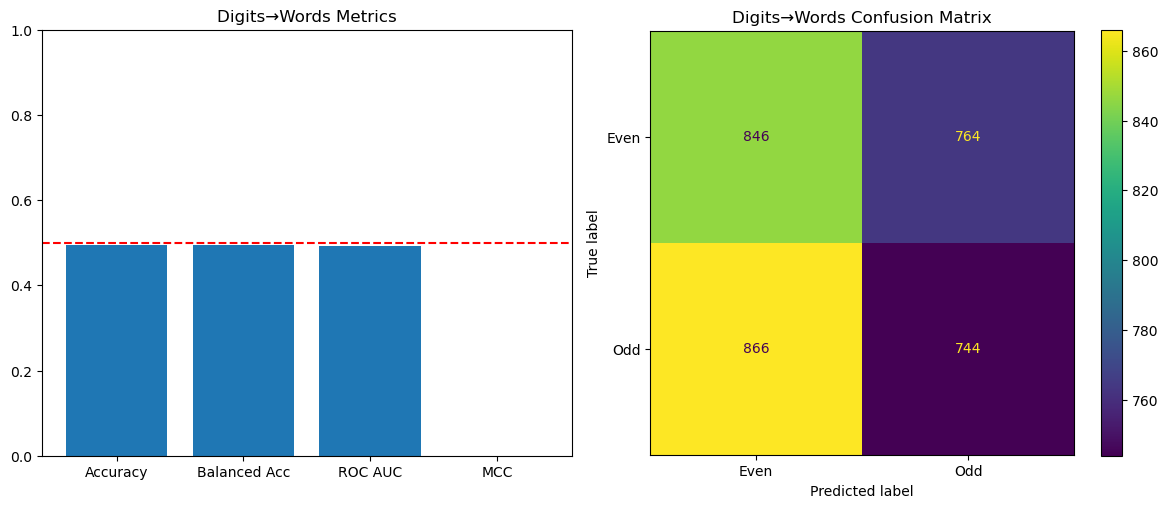

         feature  importance
7    homogeneity    0.106224
9    correlation    0.105921
1          theta    0.102764
0          delta    0.101340
6  dissimilarity    0.100891

Words→Digits Performance:
Accuracy: 0.492 (Chance: 0.5)
Balanced Accuracy: 0.492
ROC AUC: 0.497
Matthews CC: -0.016
Support: 3220 samples


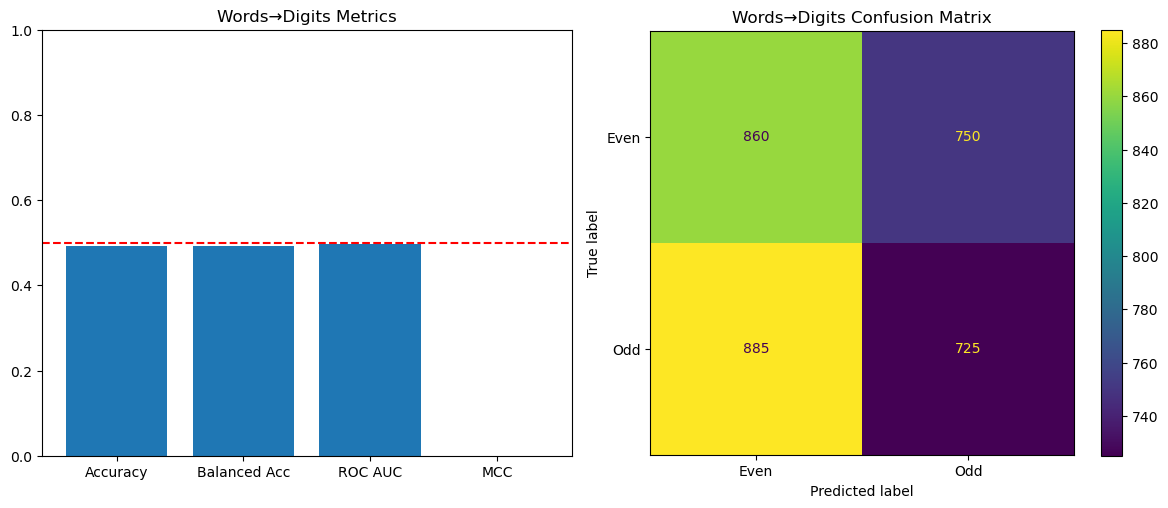

         feature  importance
6  dissimilarity    0.118582
0          delta    0.108756
9    correlation    0.105238
8         energy    0.101481
4          gamma    0.100514


In [6]:
for name, result in [('Digits→Words', dig_to_words), 
                    ('Words→Digits', words_to_dig)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {result['support']} samples")
        plot_diagnostics(result, name)
        print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

#### Null-model comparison

In [ ]:
for modality in ['Dig', 'NumWo']:
    X, y, _ = load_modality_data(base_dir, subjects, modality, font, condition)
    if not X.empty:
        null_acc = max(y.mean(), 1 - y.mean()) 
        print(f"{modality} null accuracy: {null_acc:.3f}")

### Within-modality

#### Digits

In [7]:
dig_results = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'within')

#### Number Words (Within Modality)

In [8]:
numwo_results = evaluate_modality(base_dir, subjects, 'NumWo', font, condition, 'within')

#### Plotting diagnostics


Digits Performance:
Accuracy: 0.908 (Chance: 0.5)
Balanced Accuracy: 0.908
ROC AUC: 0.975
Matthews CC: 0.816
Support: 3220 samples


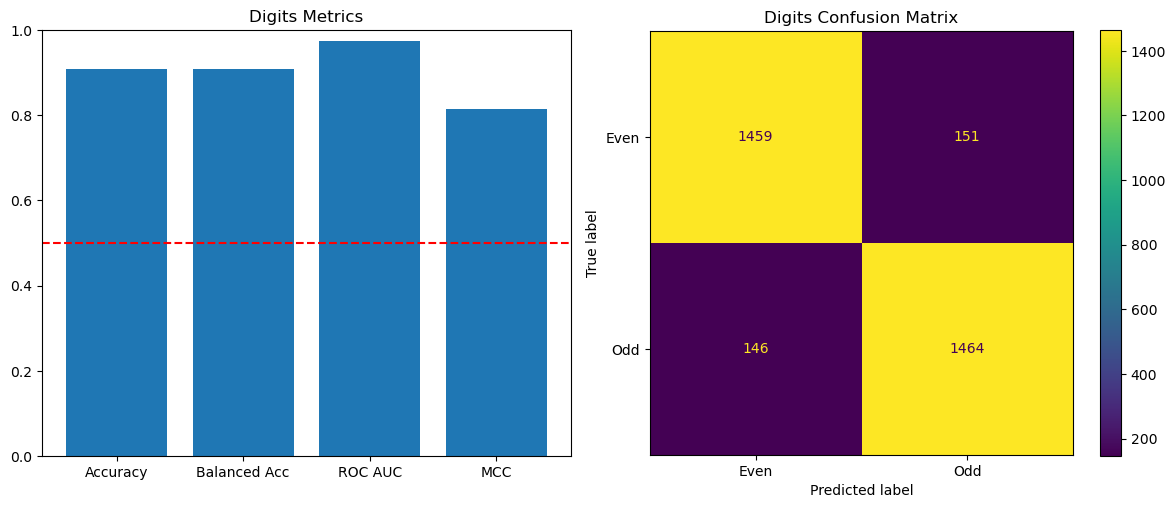

         feature  importance
7    homogeneity    0.106224
9    correlation    0.105921
1          theta    0.102764
0          delta    0.101340
6  dissimilarity    0.100891

Number Words Performance:
Accuracy: 0.917 (Chance: 0.5)
Balanced Accuracy: 0.917
ROC AUC: 0.976
Matthews CC: 0.834
Support: 3220 samples


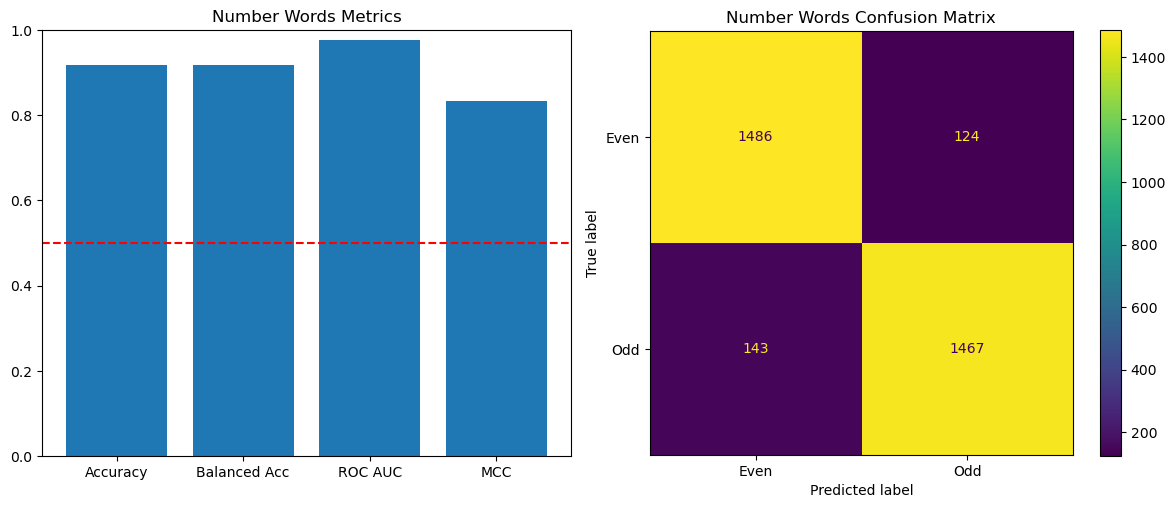

         feature  importance
6  dissimilarity    0.118582
0          delta    0.108756
9    correlation    0.105238
8         energy    0.101481
4          gamma    0.100514


In [9]:
for name, result in [('Digits', dig_results), 
                    ('Number Words', numwo_results)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {result['support']} samples")
        plot_diagnostics(result, name)
        print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

#### Null Model Comparison

In [ ]:
for modality in ['Dig', 'NumWo']:
    X, y, _ = load_modality_data(base_dir, subjects, modality, font, condition)
    if not X.empty:
        null_acc = max(y.mean(), 1 - y.mean()) 
        print(f"{modality} null accuracy: {null_acc:.3f}")

### Mixed modality

#### Mixed → Digits

In [10]:
mixed_to_digits = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'mixed', 'Dig')

#### Mixed → Number Words

In [11]:
mixed_to_words = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'mixed', 'NumWo')

#### Plotting diagnostics


Mixed→Digits Performance:
Accuracy: 0.849 (Chance: 0.5)
Balanced Accuracy: 0.849
ROC AUC: 0.935
Matthews CC: 0.698
Support: 3220 samples


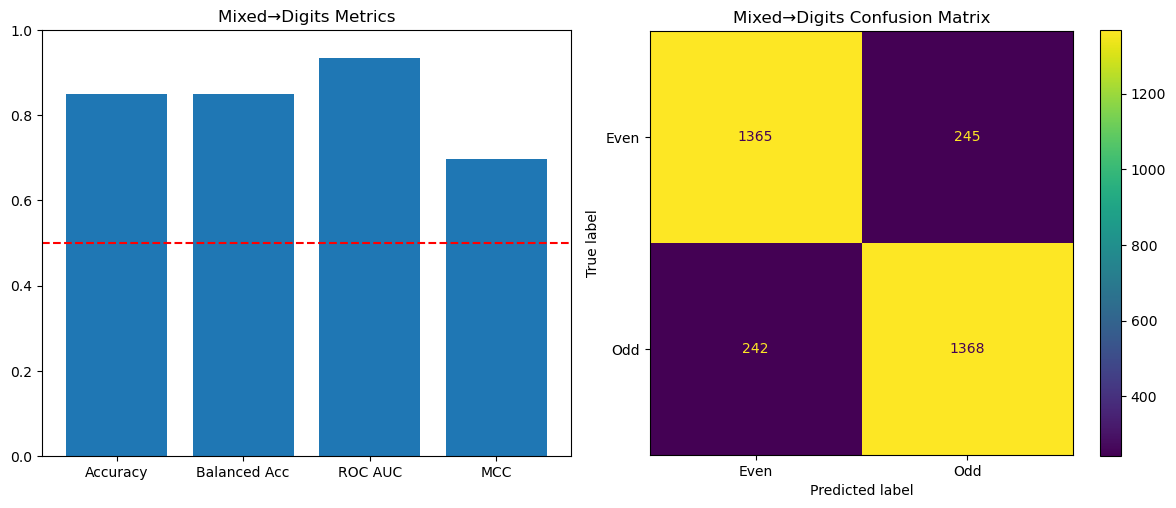

         feature  importance
8         energy    0.106417
7    homogeneity    0.104151
4          gamma    0.102940
6  dissimilarity    0.102667
1          theta    0.101291

Mixed→Words Performance:
Accuracy: 0.866 (Chance: 0.5)
Balanced Accuracy: 0.866
ROC AUC: 0.949
Matthews CC: 0.733
Support: 3220 samples


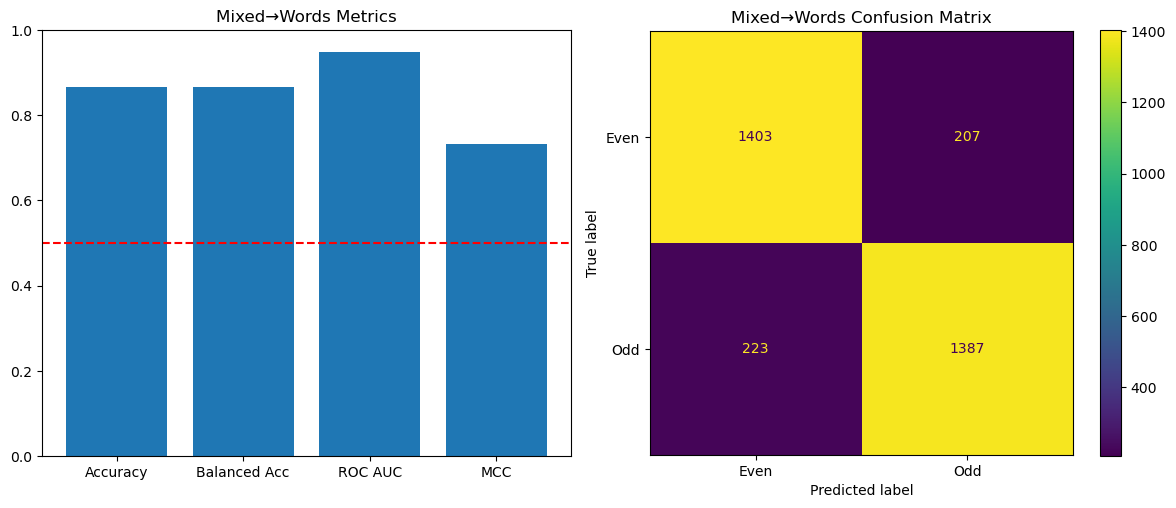

         feature  importance
8         energy    0.106417
7    homogeneity    0.104151
4          gamma    0.102940
6  dissimilarity    0.102667
1          theta    0.101291


In [12]:
for name, result in [('Mixed→Digits', mixed_to_digits), 
                    ('Mixed→Words', mixed_to_words)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {result['support']} samples")
        plot_diagnostics(result, name)
        print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

## Augmented

### Font separation

#### 1F → 20F (S)

In [ ]:
dig_1_20s = aug_evaluate_modality(base_dir, subjects, 'Dig', 
                     '1F', '20F/S', 
                     'Parity', mode='within')


1F → 20F (S) Performance:
Accuracy: 0.908 (Chance: 0.5)
Balanced Accuracy: 0.908
ROC AUC: 0.975
Matthews CC: 0.816
Support: 3220 samples


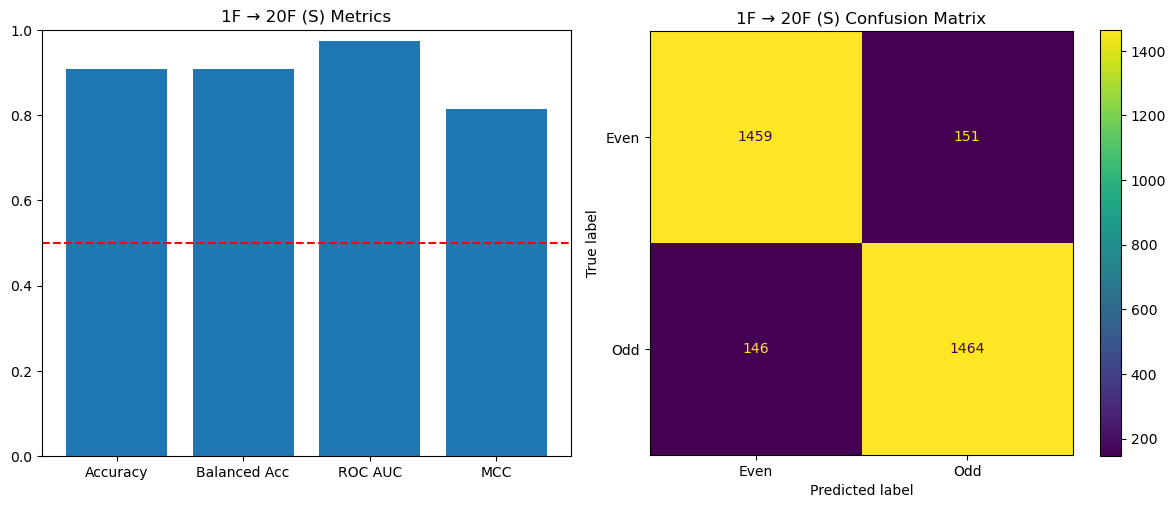

         feature  importance
7    homogeneity    0.106224
9    correlation    0.105921
1          theta    0.102764
0          delta    0.101340
6  dissimilarity    0.100891


In [10]:
for name, result in [('1F → 20F (S)', dig_1_20s)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {result['support']} samples")
        plot_diagnostics(result, name)
        print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")